Saved /content/plots/methods_note.md
Loaded final data.
Saved /content/plots/01_ethnocentrism_strategy_evolution_with_sd.png


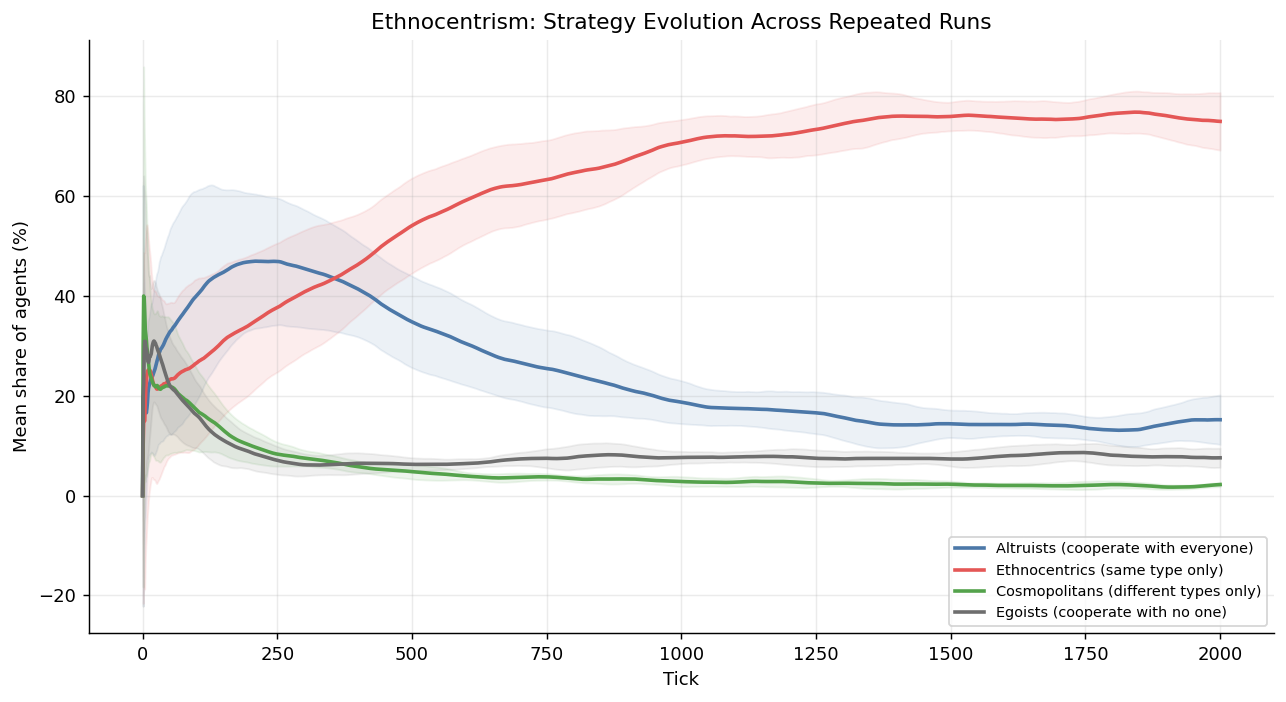

Saved /content/plots/02_ethnocentrism_final_shares_default_vs_altruist.png


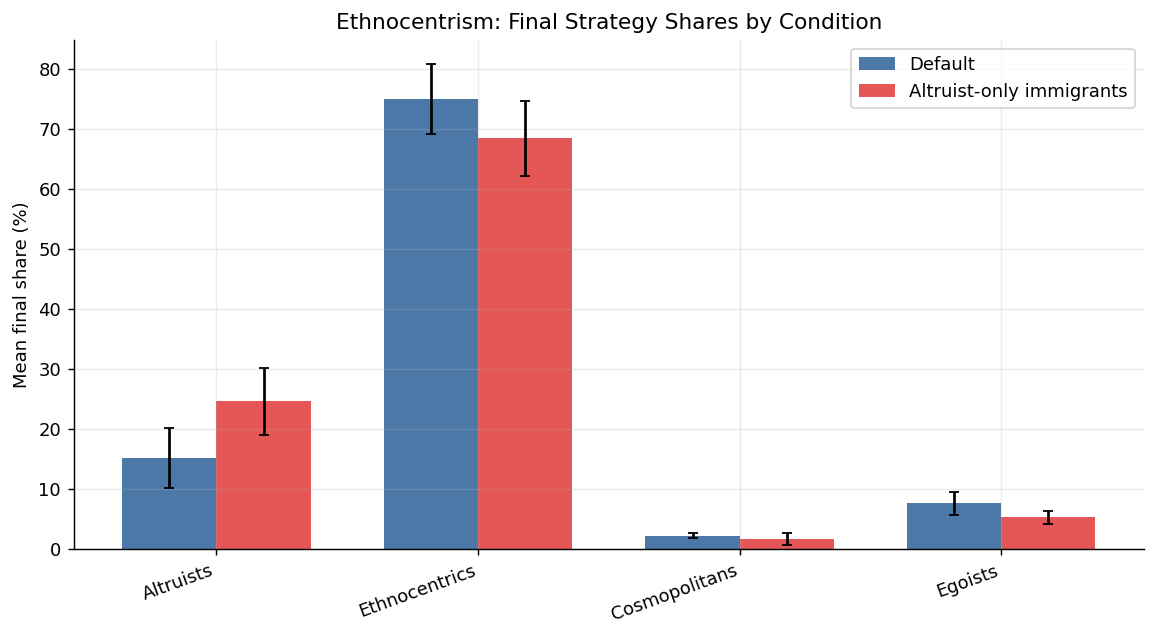

Saved /content/plots/03a_ethnocentrism_cost_gain_ethnocentric_heatmap.png


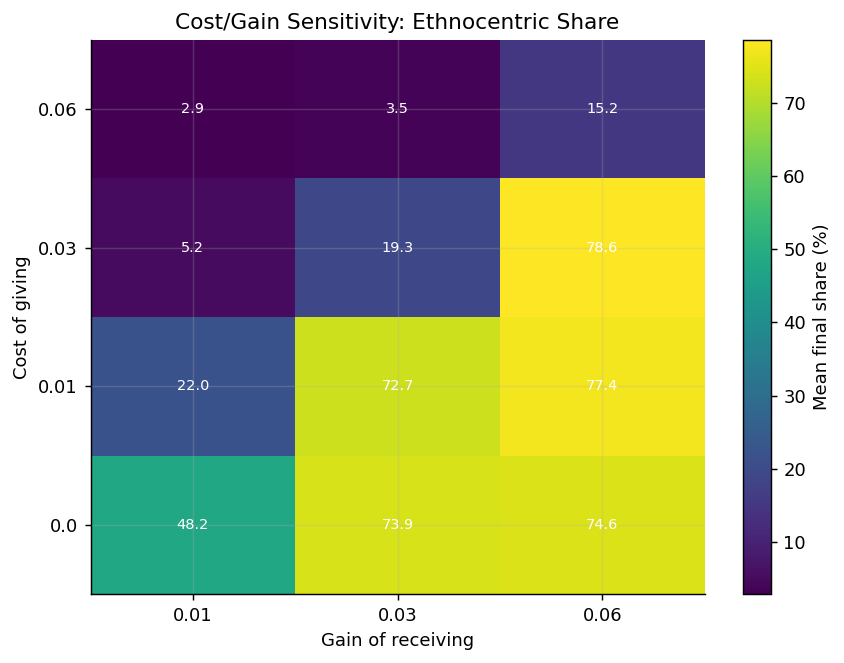

Saved /content/plots/03b_ethnocentrism_cost_gain_egoist_heatmap.png


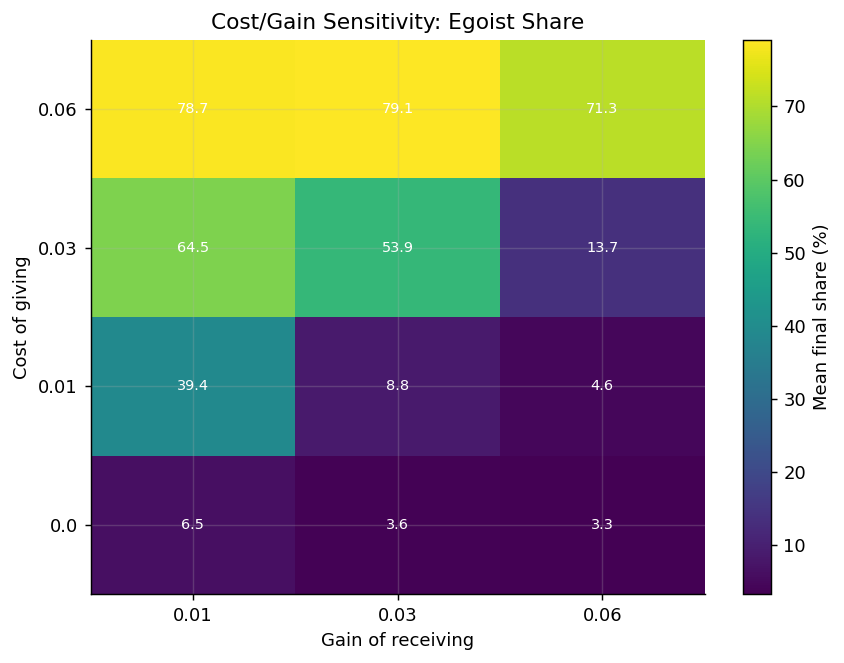

Saved /content/plots/03c_ethnocentrism_cost_gain_cooperation_heatmap.png


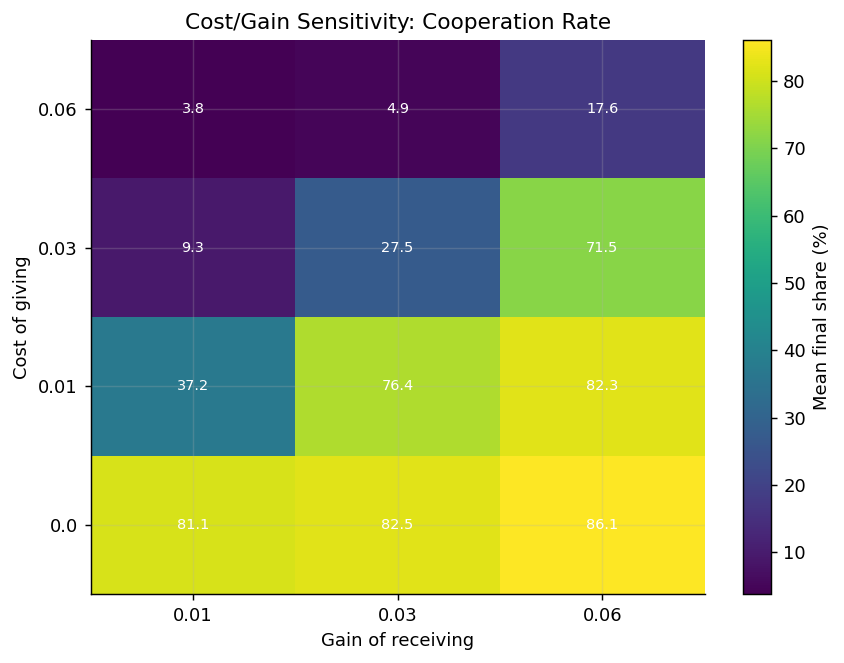

Saved /content/plots/04_ethnocentrism_stage_checkpoints.png


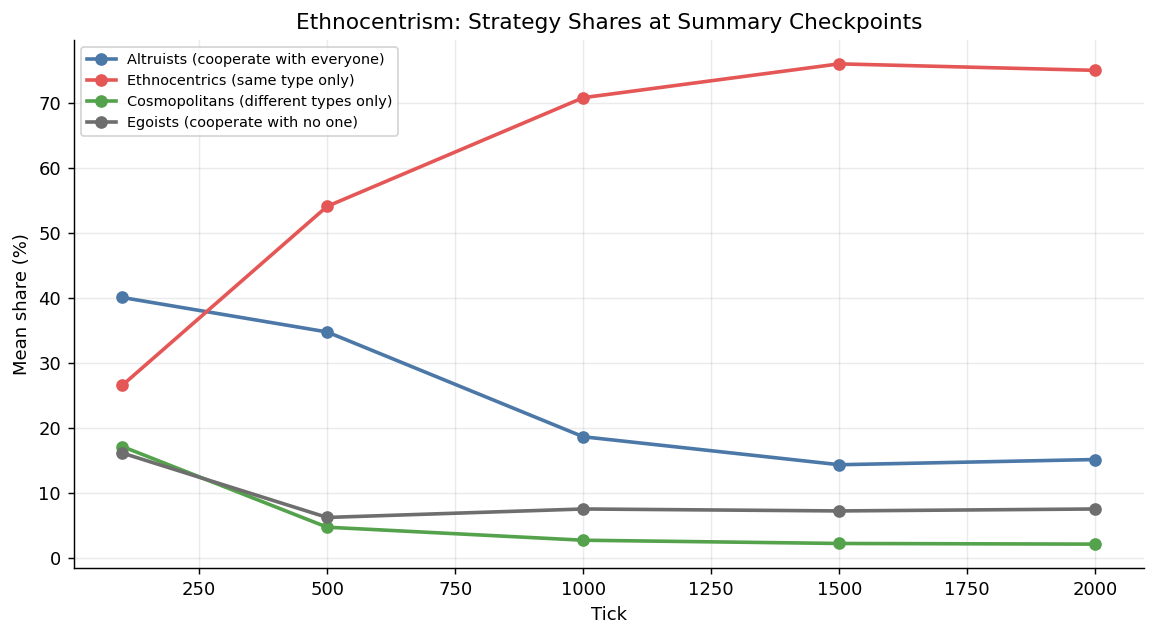

Saved /content/plots/05_rebellion_movement_active_over_time.png


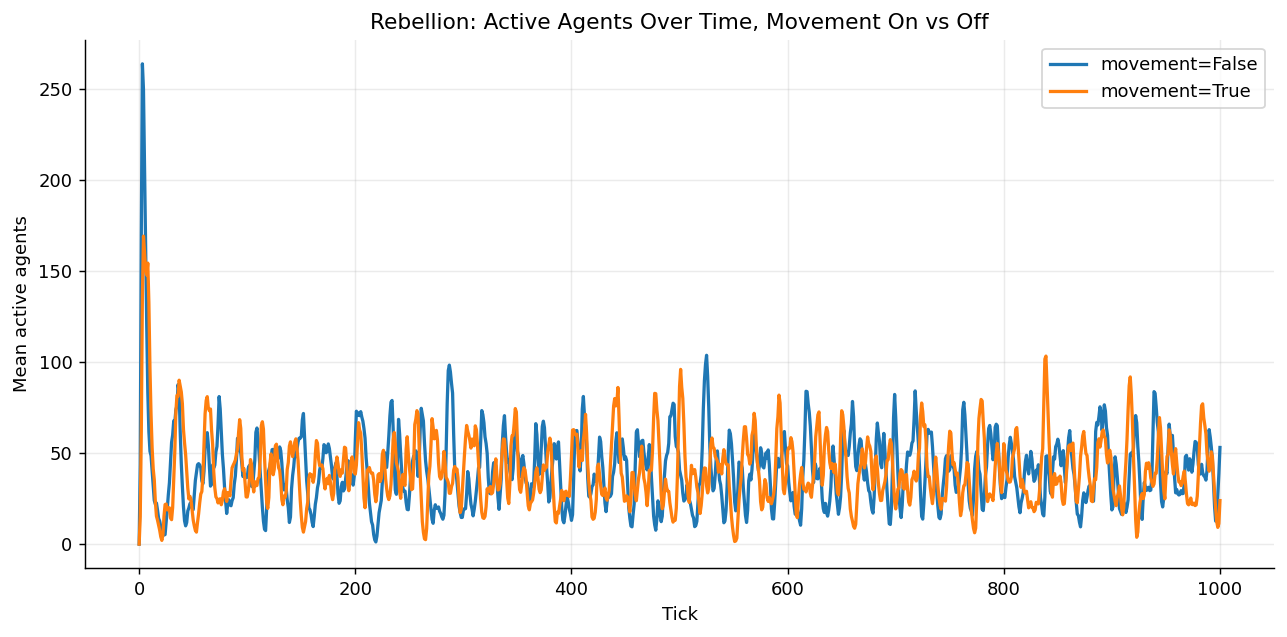

Saved /content/plots/06_rebellion_group_summary_dashboard.png


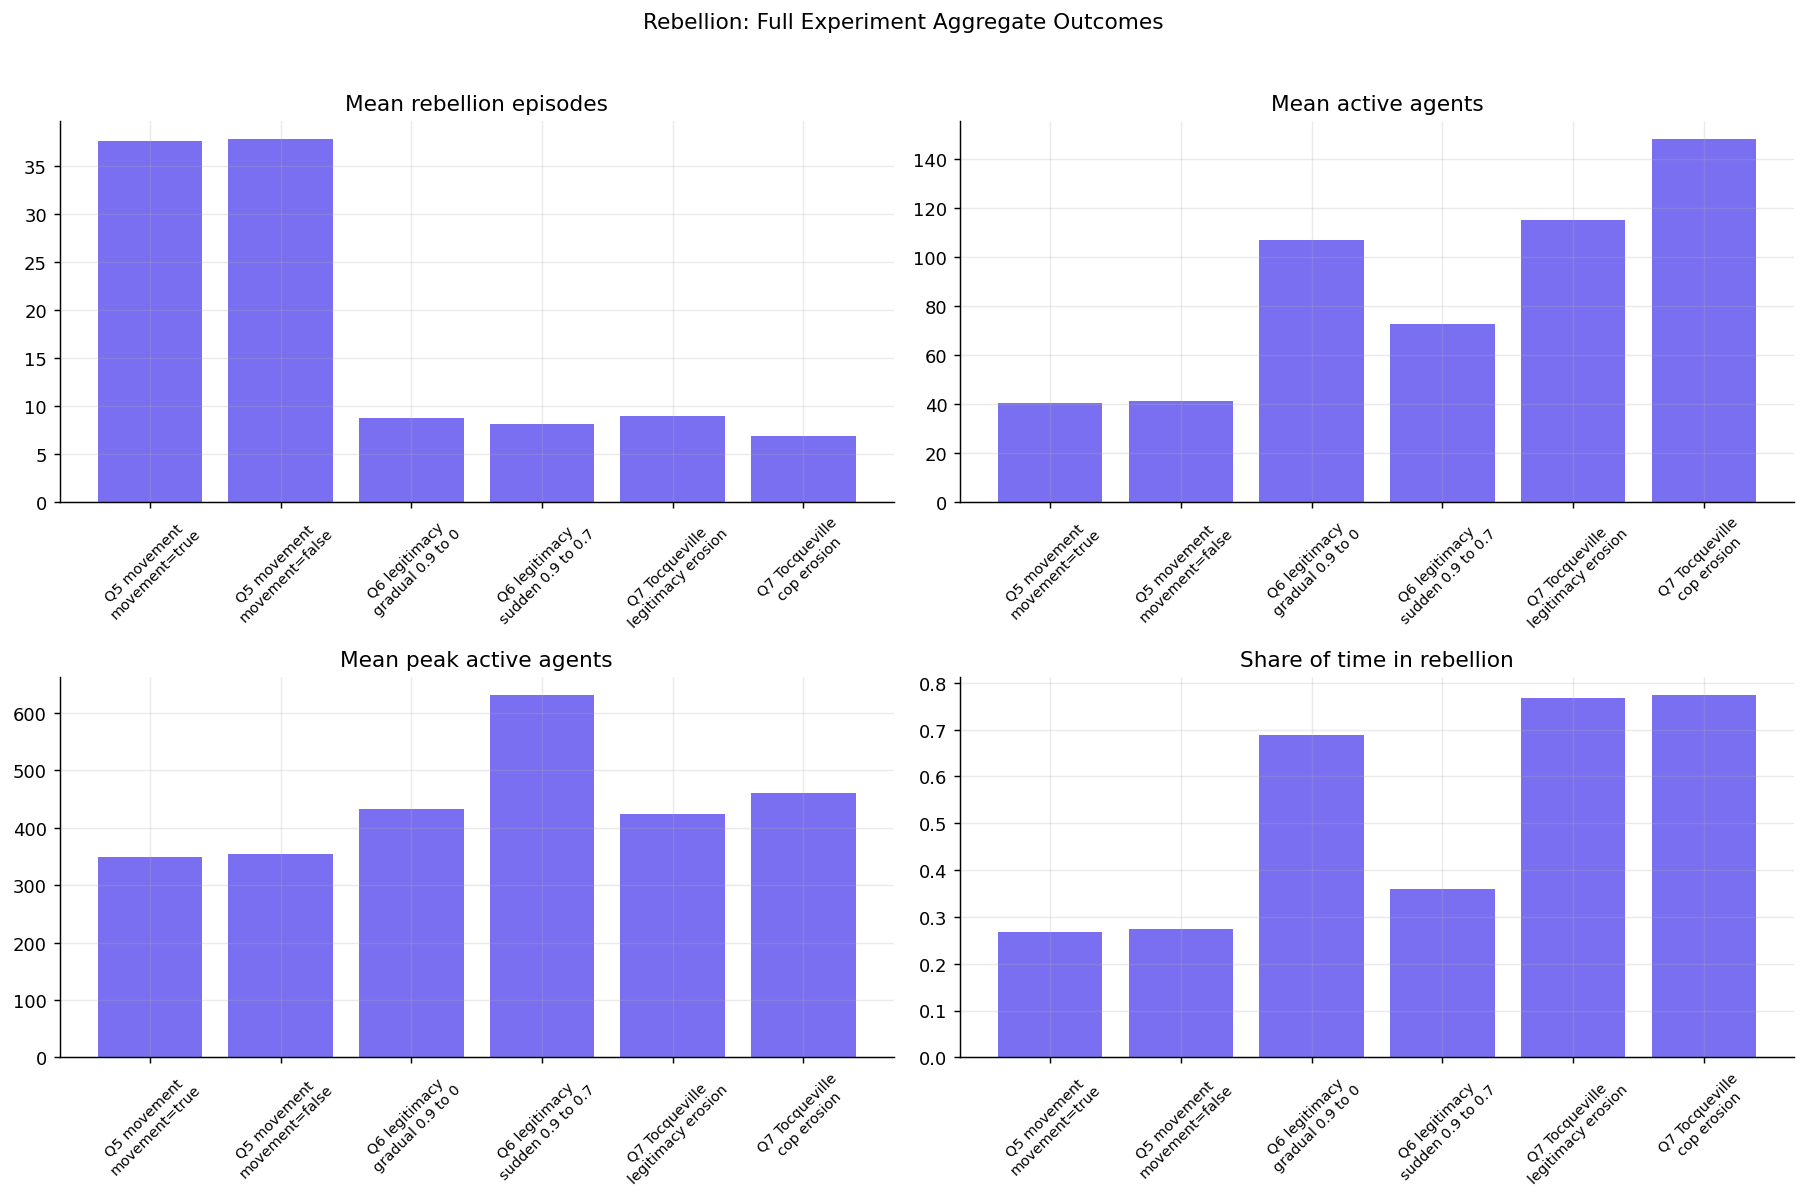

Saved /content/plots/07_rebellion_run_level_boxplots.png


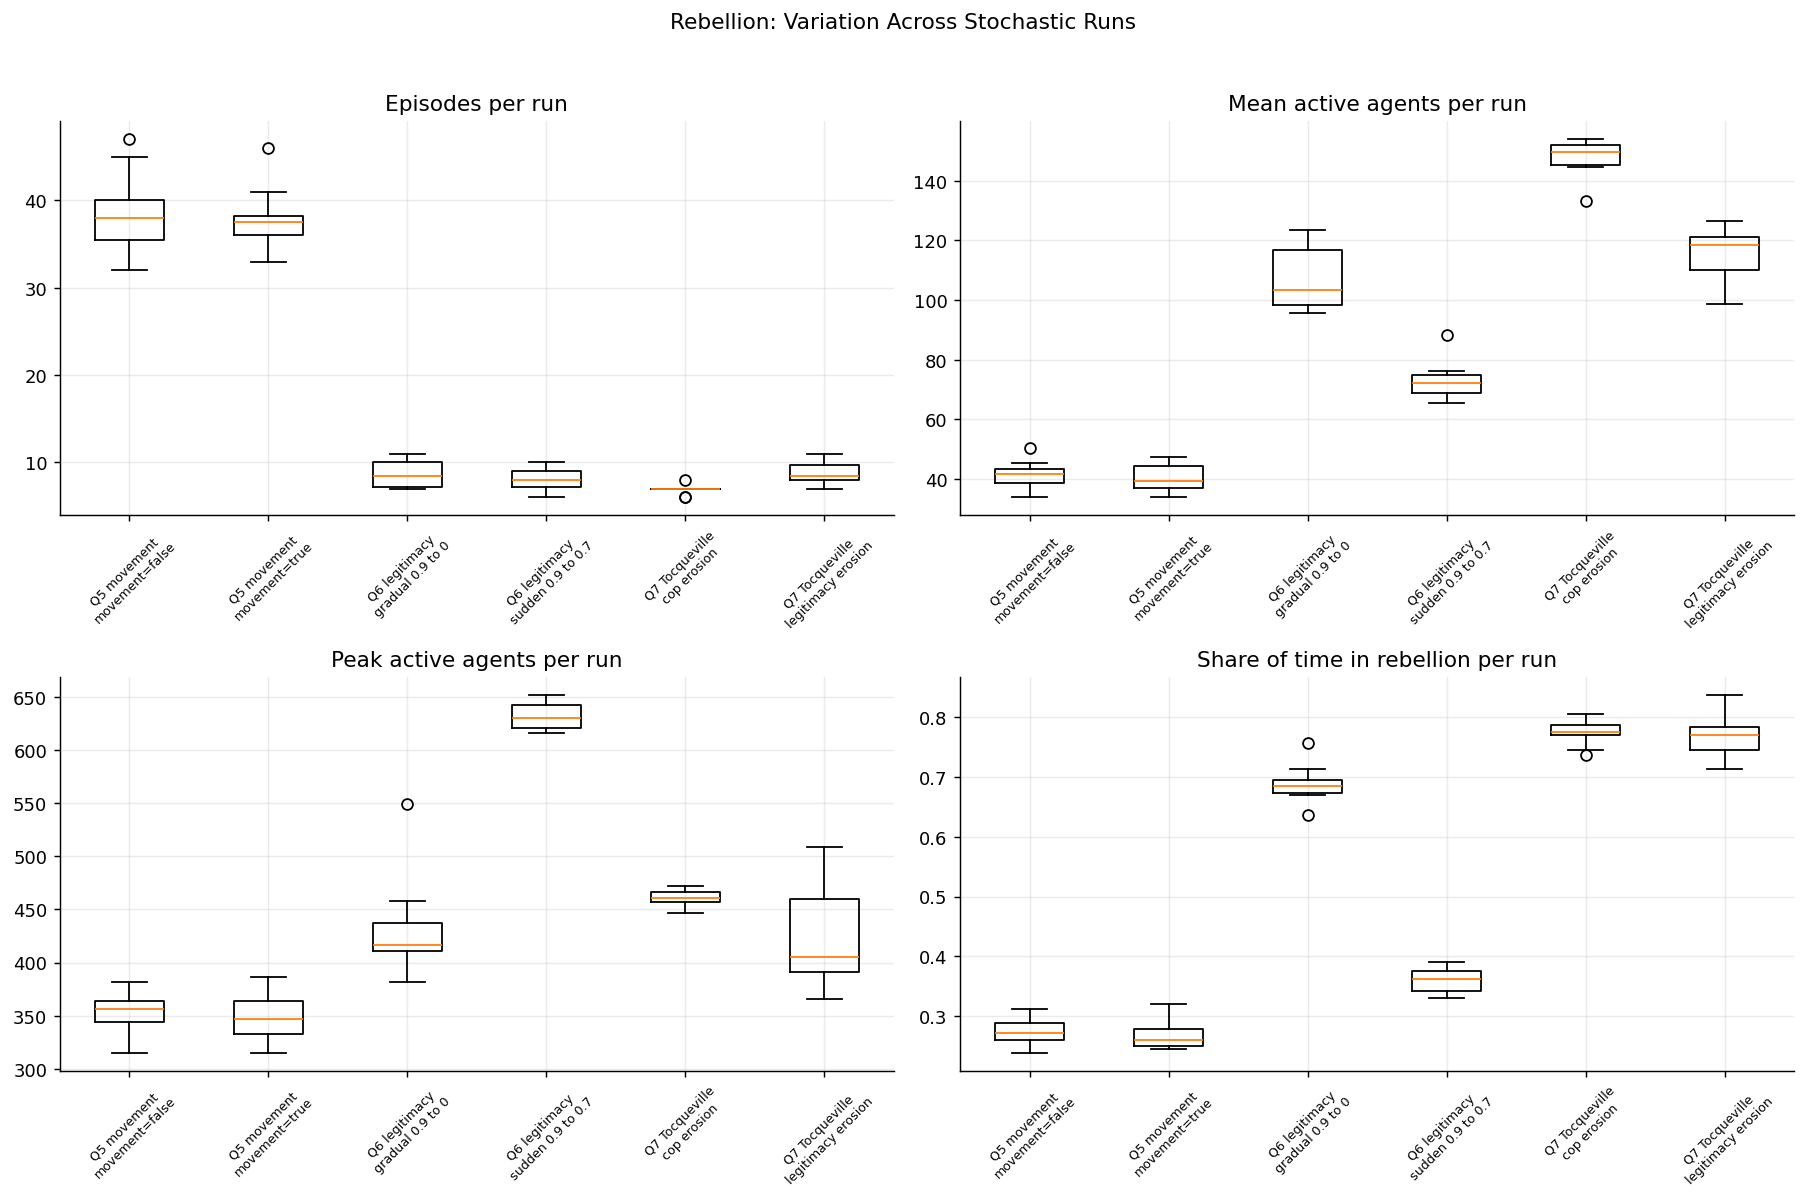

Saved /content/plots/08_rebellion_q6_legitimacy_time_series.png


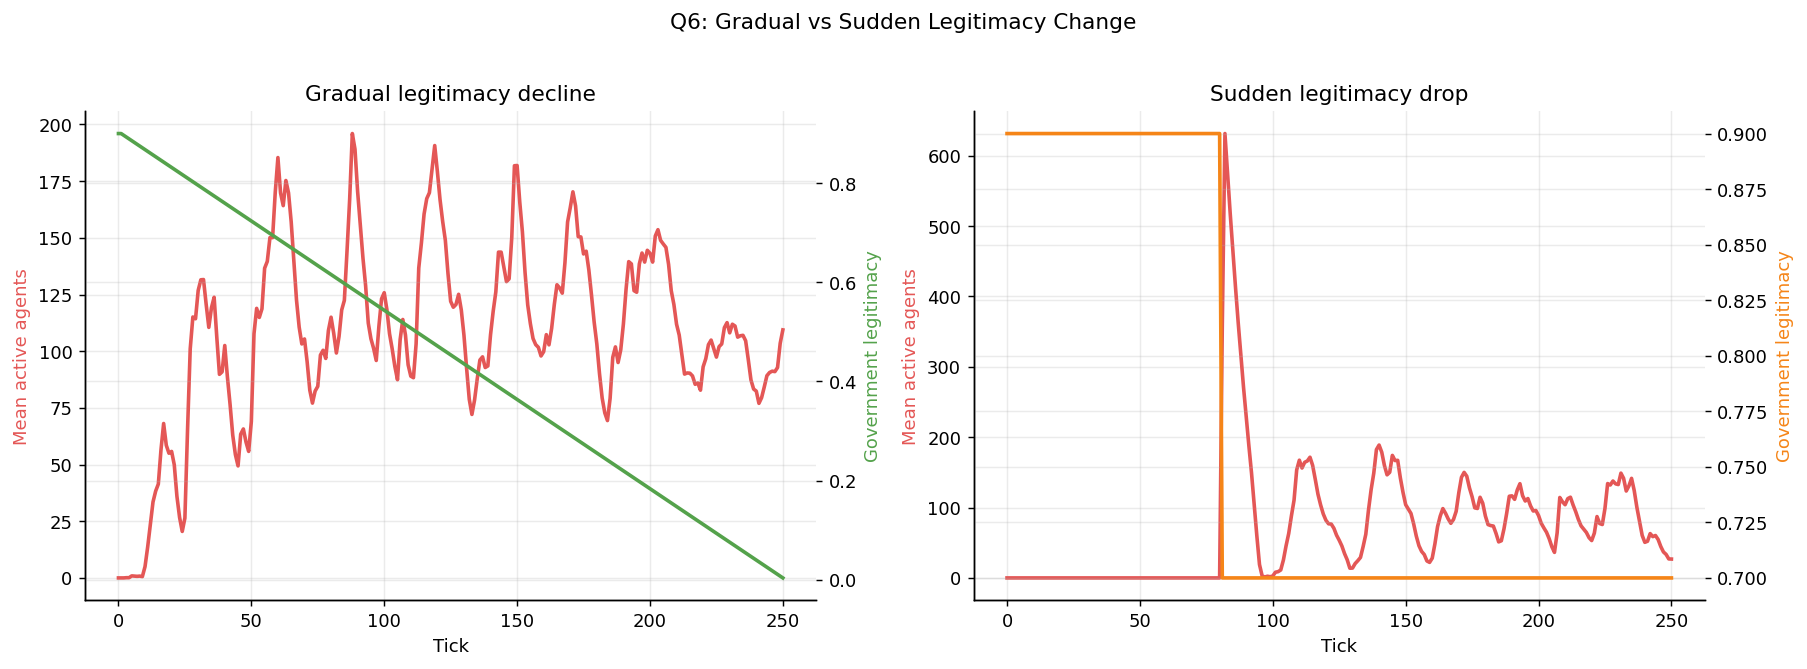

Saved /content/plots/09_rebellion_q7_tocqueville_time_series.png


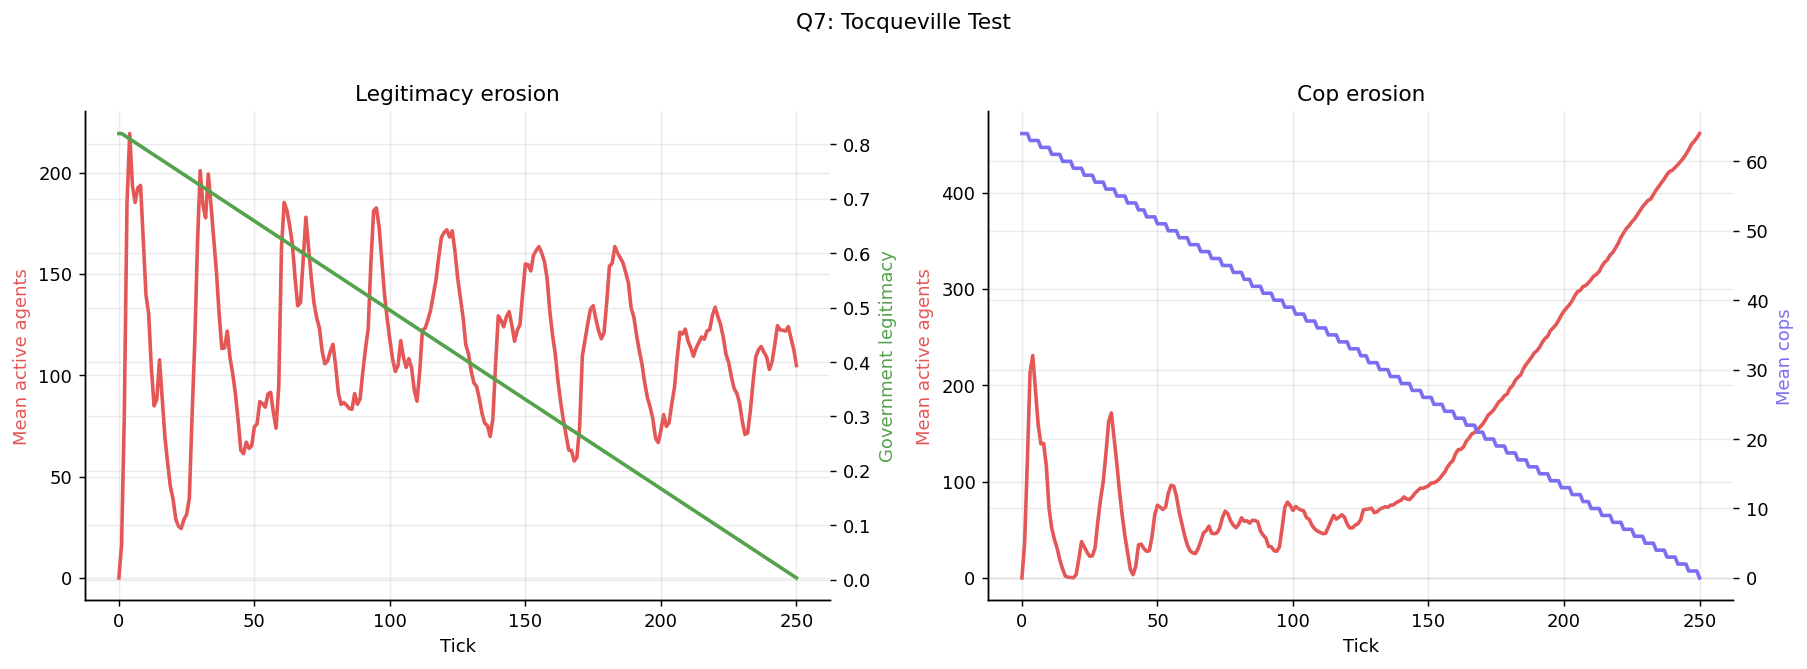

Saved /content/plots/10_focused_final_report_comparisons.png


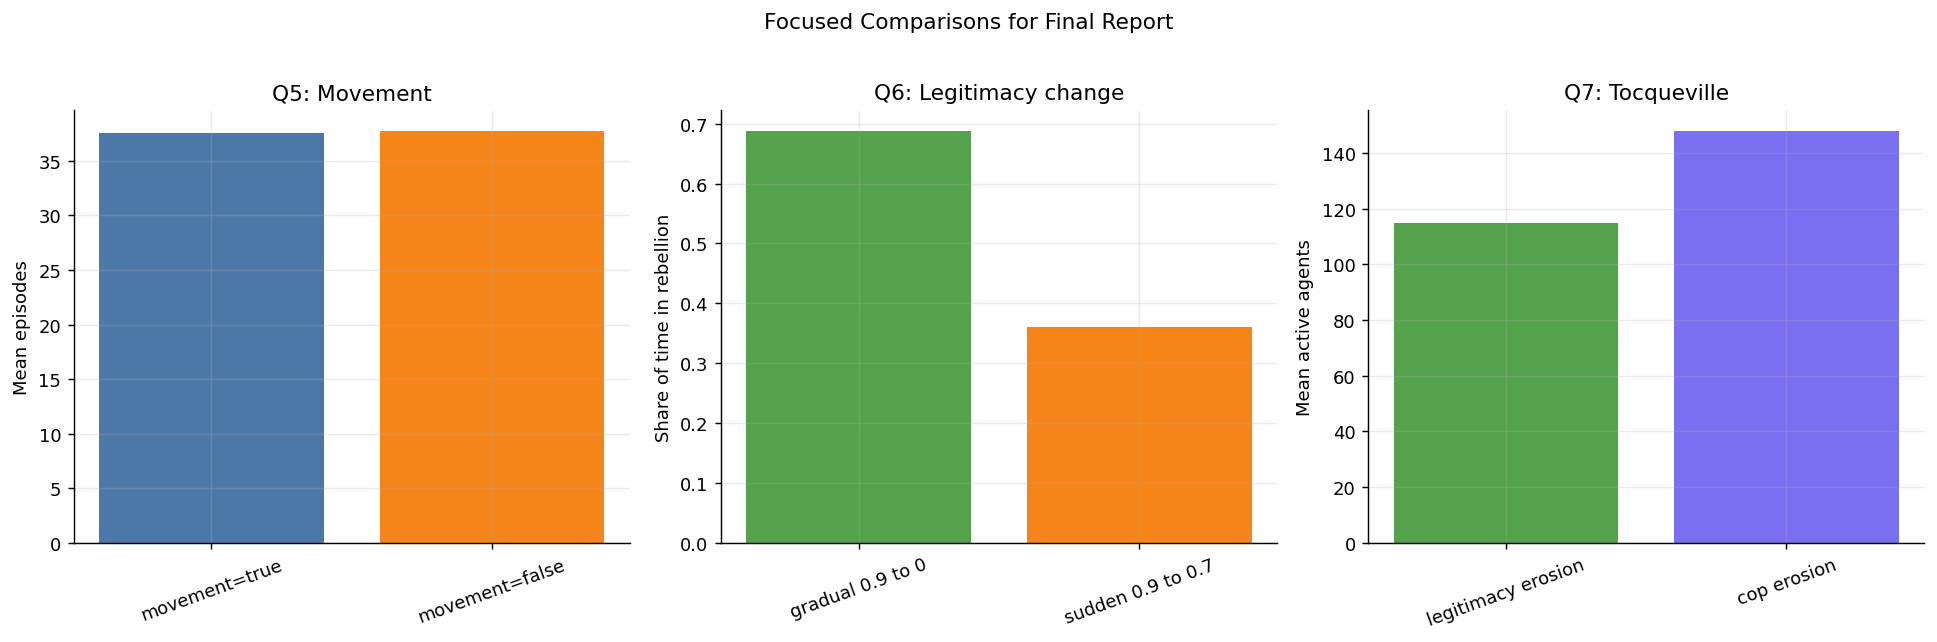


Done.
Plots folder: /content/plots
Downloadable plot zip: /content/plots.zip
- 01_ethnocentrism_strategy_evolution_with_sd.png
- 02_ethnocentrism_final_shares_default_vs_altruist.png
- 03a_ethnocentrism_cost_gain_ethnocentric_heatmap.png
- 03b_ethnocentrism_cost_gain_egoist_heatmap.png
- 03c_ethnocentrism_cost_gain_cooperation_heatmap.png
- 04_ethnocentrism_stage_checkpoints.png
- 05_rebellion_movement_active_over_time.png
- 06_rebellion_group_summary_dashboard.png
- 07_rebellion_run_level_boxplots.png
- 08_rebellion_q6_legitimacy_time_series.png
- 09_rebellion_q7_tocqueville_time_series.png
- 10_focused_final_report_comparisons.png
- methods_note.md


In [3]:
# Colab single-cell script: full NetLogo results plots + methods framing.
#
# How to use:
# 1. In Google Colab, upload `final_full_results_clean_data.zip` into /content.
#    You can also upload the CSVs directly; the script searches recursively.
# 2. Paste this entire file into one Colab cell and run it.
# 3. Figures are displayed inline and saved to `/content/plots`.
# 4. A methods note is saved to `/content/plots/methods_note.md`.
#
# Methodological framing used in the analysis:
# - Operationalization: social theory is translated into explicit agent rules
#   and measurable outcomes.
# - Repeated stochastic runs: results are averaged across replications rather
#   than interpreted from a single run.
# - Scenario comparison: one theoretical mechanism is changed at a time
#   while other model settings are held fixed.
# - Sensitivity / parameter exploration: cost and gain are varied in the
#   Ethnocentrism model to test whether the qualitative pattern is robust.
# - Aggregation from micro to macro: agent states are summarized into
#   population-level strategy shares, active rebellion, peak rebellion, and
#   episode counts.
# - Validation-style reasoning: Rebellion patterns are compared against
#   historical cases, while acknowledging that this is exploratory rather than
#   full formal model validation.

import os
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


ROOT = Path("/content") if Path("/content").exists() else Path.cwd()
PLOTS = ROOT / "plots"
PLOTS.mkdir(exist_ok=True)


plt.rcParams.update({
    "figure.figsize": (9, 5),
    "figure.dpi": 130,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})


COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "red": "#E45756",
    "green": "#54A24B",
    "purple": "#7A6FF0",
    "teal": "#72B7B2",
    "gray": "#6E6E6E",
}


def maybe_extract_zip():
    zip_names = [
        "final_full_results_clean_data.zip",
        "netlogo_results_package.zip",
        "rebellion_full_results_only.zip",
    ]
    for name in zip_names:
        zpath = ROOT / name
        if zpath.exists():
            target = ROOT / zpath.stem
            if not target.exists():
                print(f"Extracting {zpath.name} -> {target}")
                with zipfile.ZipFile(zpath, "r") as zf:
                    zf.extractall(target)
            return target
    return ROOT


DATA_ROOT = maybe_extract_zip()


def find_file(*names):
    """Find a file by filename under extracted data or Colab root."""
    for base in [DATA_ROOT, ROOT]:
        for name in names:
            direct = base / name
            if direct.exists():
                return direct
        for path in base.rglob("*"):
            if path.is_file() and path.name in names:
                return path
    raise FileNotFoundError(f"Could not find any of: {names}")


def read_behaviorspace_csv(path):
    """Read a NetLogo BehaviorSpace CSV with metadata rows before the data header."""
    path = Path(path)
    lines = path.read_text(encoding="utf-8-sig", errors="replace").splitlines()
    header_idx = None
    for i, line in enumerate(lines):
        if line.startswith('"[run number]"') or line.startswith("[run number]"):
            header_idx = i
            break
    if header_idx is None:
        df = pd.read_csv(path)
    else:
        df = pd.read_csv(path, skiprows=header_idx)
    df.columns = [str(c).strip() for c in df.columns]
    if "government-legitimacy.1" in df.columns:
        df = df.rename(columns={"government-legitimacy.1": "government-legitimacy-output"})
    return df


def to_numeric(df, cols):
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def savefig(name):
    path = PLOTS / name
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    print(f"Saved {path}")
    plt.show()


def write_methods_note():
    text = """# Methods Note

This analysis follows the simulation workflow discussed in the course readings:

1. Operationalization of theory: homophily/ethnocentrism and civic unrest are translated into explicit NetLogo agent rules.
2. Model execution: pre-built NetLogo ABMs are run through BehaviorSpace.
3. Repeated stochastic runs: random simulation outcomes are summarized across repetitions.
4. Controlled scenario comparison: one focal mechanism is varied at a time, such as movement, legitimacy, cost/gain, or police capacity.
5. Sensitivity-style exploration: Ethnocentrism cost/gain settings are varied to see whether conclusions change.
6. Macro-level interpretation: individual agent rules are aggregated into strategy shares, rebellion episodes, active agents, and peak unrest.
7. Validation-style reasoning: simulated patterns are compared with historical cases, while noting that this is exploratory and not full formal validation.
"""
    (PLOTS / "methods_note.md").write_text(text, encoding="utf-8")
    print(f"Saved {PLOTS / 'methods_note.md'}")


write_methods_note()


# Load final raw and aggregated data

ethno_default = read_behaviorspace_csv(find_file("ethnocentrism_default_timeseries_raw.csv", "ethno_default_timeseries.csv"))
ethno_altruist = read_behaviorspace_csv(find_file("ethnocentrism_altruist_immigrants_raw.csv", "ethno_altruist_immigrants.csv"))
ethno_cost_gain = read_behaviorspace_csv(find_file("ethnocentrism_cost_gain_grid_raw.csv", "ethno_cost_gain_grid.csv"))

ethno_default_agg = pd.read_csv(find_file("ethnocentrism_default_final_aggregated.csv"))
ethno_altruist_agg = pd.read_csv(find_file("ethnocentrism_altruist_final_aggregated.csv"))
ethno_stage_agg = pd.read_csv(find_file("ethnocentrism_default_stage_aggregated.csv"))
ethno_cost_gain_agg = pd.read_csv(find_file("ethnocentrism_cost_gain_aggregated.csv"))

reb_movement = read_behaviorspace_csv(find_file("rebellion_full_movement_raw.csv", "rebellion_full_movement.csv"))
reb_leg_grad = read_behaviorspace_csv(find_file("rebellion_full_legitimacy_gradual_raw.csv", "rebellion_full_legitimacy_gradual.csv"))
reb_leg_sudden = read_behaviorspace_csv(find_file("rebellion_full_legitimacy_sudden_raw.csv", "rebellion_full_legitimacy_sudden.csv"))
reb_tocq_leg = read_behaviorspace_csv(find_file("rebellion_full_tocqueville_legitimacy_raw.csv", "rebellion_full_tocqueville_legitimacy.csv"))
reb_tocq_cops = read_behaviorspace_csv(find_file("rebellion_full_tocqueville_cops_raw.csv", "rebellion_full_tocqueville_cops.csv"))

reb_group = pd.read_csv(find_file("rebellion_full_group_aggregated.csv", "rebellion_full_group_summary.csv"))
reb_run = pd.read_csv(find_file("rebellion_full_run_aggregated.csv", "rebellion_full_run_summary.csv"))

print("Loaded final data.")


# Plot 1: Ethnocentrism strategy evolution over time

strategy_cols = ["cc-percent", "cd-percent", "dc-percent", "dd-percent"]
ethno_default = to_numeric(ethno_default, ["[step]"] + strategy_cols)
evo_mean = ethno_default.groupby("[step]")[strategy_cols].mean()
evo_sd = ethno_default.groupby("[step]")[strategy_cols].std()

labels = {
    "cc-percent": "Altruists (cooperate with everyone)",
    "cd-percent": "Ethnocentrics (same type only)",
    "dc-percent": "Cosmopolitans (different types only)",
    "dd-percent": "Egoists (cooperate with no one)",
}
colors = {
    "cc-percent": COLORS["blue"],
    "cd-percent": COLORS["red"],
    "dc-percent": COLORS["green"],
    "dd-percent": COLORS["gray"],
}

plt.figure(figsize=(10, 5.5))
for col in strategy_cols:
    x = evo_mean.index.to_numpy()
    y = evo_mean[col].to_numpy() * 100
    sd = evo_sd[col].fillna(0).to_numpy() * 100
    plt.plot(x, y, linewidth=2, label=labels[col], color=colors[col])
    plt.fill_between(x, y - sd, y + sd, color=colors[col], alpha=0.10)
plt.title("Ethnocentrism: Strategy Evolution Across Repeated Runs")
plt.xlabel("Tick")
plt.ylabel("Mean share of agents (%)")
plt.legend(fontsize=8)
savefig("01_ethnocentrism_strategy_evolution_with_sd.png")


# Plot 2: Ethnocentrism final shares, default vs altruist-only immigrants

metric_to_type = {
    "cc-percent": "Altruists",
    "cd-percent": "Ethnocentrics",
    "dc-percent": "Cosmopolitans",
    "dd-percent": "Egoists",
}

def final_share_frame(df, condition):
    sub = df[df["metric"].isin(metric_to_type)].copy()
    sub["type"] = sub["metric"].map(metric_to_type)
    sub["condition"] = condition
    sub["mean_percent"] = pd.to_numeric(sub["mean"], errors="coerce") * 100
    sub["sd_percent"] = pd.to_numeric(sub["sd"], errors="coerce") * 100
    return sub[["condition", "type", "mean_percent", "sd_percent"]]

final_compare = pd.concat([
    final_share_frame(ethno_default_agg, "Default"),
    final_share_frame(ethno_altruist_agg, "Altruist-only immigrants"),
], ignore_index=True)

order = ["Altruists", "Ethnocentrics", "Cosmopolitans", "Egoists"]
x = np.arange(len(order))
width = 0.36

plt.figure(figsize=(9, 5))
for offset, condition, color in [(-width / 2, "Default", COLORS["blue"]), (width / 2, "Altruist-only immigrants", COLORS["red"])]:
    sub = final_compare[final_compare["condition"].eq(condition)].set_index("type").loc[order]
    plt.bar(x + offset, sub["mean_percent"], width, yerr=sub["sd_percent"], capsize=3, label=condition, color=color)
plt.title("Ethnocentrism: Final Strategy Shares by Condition")
plt.ylabel("Mean final share (%)")
plt.xticks(x, order, rotation=20, ha="right")
plt.legend()
savefig("02_ethnocentrism_final_shares_default_vs_altruist.png")


# Plot 3: Ethnocentrism cost/gain heatmaps

cg = ethno_cost_gain_agg.copy()
cg["gain"] = pd.to_numeric(cg["gain"], errors="coerce")
cg["cost"] = pd.to_numeric(cg["cost"], errors="coerce")
cg["mean"] = pd.to_numeric(cg["mean"], errors="coerce")

def heatmap(metric, title, filename):
    sub = cg[cg["metric"].eq(metric)]
    data = sub.pivot(index="cost", columns="gain", values="mean") * 100
    plt.figure(figsize=(6.8, 5.2))
    im = plt.imshow(data.values, origin="lower", aspect="auto", cmap="viridis")
    plt.title(title)
    plt.xlabel("Gain of receiving")
    plt.ylabel("Cost of giving")
    plt.xticks(range(len(data.columns)), [str(x) for x in data.columns])
    plt.yticks(range(len(data.index)), [str(x) for x in data.index])
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            plt.text(j, i, f"{data.values[i, j]:.1f}", ha="center", va="center", color="white", fontsize=8)
    plt.colorbar(im, label="Mean final share (%)")
    savefig(filename)

heatmap("cd-percent", "Cost/Gain Sensitivity: Ethnocentric Share", "03a_ethnocentrism_cost_gain_ethnocentric_heatmap.png")
heatmap("dd-percent", "Cost/Gain Sensitivity: Egoist Share", "03b_ethnocentrism_cost_gain_egoist_heatmap.png")
heatmap("last100coop-percent", "Cost/Gain Sensitivity: Cooperation Rate", "03c_ethnocentrism_cost_gain_cooperation_heatmap.png")


# Plot 4: Ethnocentrism stage checkpoints from aggregate data

stage = ethno_stage_agg[ethno_stage_agg["metric"].isin(strategy_cols)].copy()
stage["step"] = pd.to_numeric(stage["step"], errors="coerce")
stage["mean_percent"] = pd.to_numeric(stage["mean"], errors="coerce") * 100

plt.figure(figsize=(9, 5))
for metric in strategy_cols:
    sub = stage[stage["metric"].eq(metric)].sort_values("step")
    plt.plot(sub["step"], sub["mean_percent"], marker="o", linewidth=2, label=labels[metric], color=colors[metric])
plt.title("Ethnocentrism: Strategy Shares at Summary Checkpoints")
plt.xlabel("Tick")
plt.ylabel("Mean share (%)")
plt.legend(fontsize=8)
savefig("04_ethnocentrism_stage_checkpoints.png")


# Plot 5: Rebellion movement on/off time series

active_col = "count agents with [active?]"
jailed_col = "count agents with [jail-term > 0]"
cops_col = "count cops"
step_col = "[step]"

reb_movement = to_numeric(reb_movement, [step_col, active_col, jailed_col, cops_col])
move_avg = reb_movement.groupby(["movement?", step_col], as_index=False)[[active_col, jailed_col]].mean()

plt.figure(figsize=(10, 5))
for moved, sub in move_avg.groupby("movement?"):
    plt.plot(sub[step_col], sub[active_col], linewidth=1.8, label=f"movement={moved}")
plt.title("Rebellion: Active Agents Over Time, Movement On vs Off")
plt.xlabel("Tick")
plt.ylabel("Mean active agents")
plt.legend()
savefig("05_rebellion_movement_active_over_time.png")


# Plot 6: Rebellion group summary dashboard

reb_group = to_numeric(reb_group, ["mean_episodes", "mean_active", "peak_active_mean", "share_rebellion_mean"])
reb_group["label"] = reb_group["scenario"].astype(str) + "\n" + reb_group["condition"].astype(str)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
dash_specs = [
    ("mean_episodes", "Mean rebellion episodes"),
    ("mean_active", "Mean active agents"),
    ("peak_active_mean", "Mean peak active agents"),
    ("share_rebellion_mean", "Share of time in rebellion"),
]
for ax, (col, title) in zip(axes.ravel(), dash_specs):
    ax.bar(reb_group["label"], reb_group[col], color=COLORS["purple"])
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
plt.suptitle("Rebellion: Full Experiment Aggregate Outcomes", y=1.02)
savefig("06_rebellion_group_summary_dashboard.png")


# Plot 7: Rebellion run-level boxplots

reb_run["scenario_condition"] = reb_run["scenario"].astype(str) + "\n" + reb_run["condition"].astype(str)
reb_run = to_numeric(reb_run, ["episodes", "mean_active", "peak_active", "share_rebellion"])

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
box_specs = [
    ("episodes", "Episodes per run"),
    ("mean_active", "Mean active agents per run"),
    ("peak_active", "Peak active agents per run"),
    ("share_rebellion", "Share of time in rebellion per run"),
]
for ax, (col, title) in zip(axes.ravel(), box_specs):
    groups = [g[col].dropna().to_numpy() for _, g in reb_run.groupby("scenario_condition")]
    labels_box = list(reb_run.groupby("scenario_condition").groups.keys())
    ax.boxplot(groups, tick_labels=labels_box)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
plt.suptitle("Rebellion: Variation Across Stochastic Runs", y=1.02)
savefig("07_rebellion_run_level_boxplots.png")


# Plot 8: Q6 legitimacy scenarios over time

def prep_legitimacy(df):
    df = df.copy()
    if "government-legitimacy-output" in df.columns:
        leg_col = "government-legitimacy-output"
    else:
        leg_col = "government-legitimacy"
    df = to_numeric(df, [step_col, active_col, jailed_col, cops_col, leg_col])
    avg = df.groupby(step_col, as_index=False)[[active_col, leg_col]].mean()
    return avg, leg_col

grad_avg, grad_leg_col = prep_legitimacy(reb_leg_grad)
sudden_avg, sudden_leg_col = prep_legitimacy(reb_leg_sudden)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, avg, leg_col, title, color in [
    (axes[0], grad_avg, grad_leg_col, "Gradual legitimacy decline", COLORS["green"]),
    (axes[1], sudden_avg, sudden_leg_col, "Sudden legitimacy drop", COLORS["orange"]),
]:
    ax2 = ax.twinx()
    ax.plot(avg[step_col], avg[active_col], color=COLORS["red"], linewidth=2, label="Active agents")
    ax2.plot(avg[step_col], avg[leg_col], color=color, linewidth=2, label="Legitimacy")
    ax.set_title(title)
    ax.set_xlabel("Tick")
    ax.set_ylabel("Mean active agents", color=COLORS["red"])
    ax2.set_ylabel("Government legitimacy", color=color)
plt.suptitle("Q6: Gradual vs Sudden Legitimacy Change", y=1.02)
savefig("08_rebellion_q6_legitimacy_time_series.png")


# Plot 9: Q7 Tocqueville scenarios over time

tocq_leg_avg, tocq_leg_col = prep_legitimacy(reb_tocq_leg)
reb_tocq_cops = to_numeric(reb_tocq_cops, [step_col, active_col, jailed_col, cops_col, "government-legitimacy"])
tocq_cops_avg = reb_tocq_cops.groupby(step_col, as_index=False)[[active_col, cops_col]].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax2 = ax.twinx()
ax.plot(tocq_leg_avg[step_col], tocq_leg_avg[active_col], color=COLORS["red"], linewidth=2, label="Active agents")
ax2.plot(tocq_leg_avg[step_col], tocq_leg_avg[tocq_leg_col], color=COLORS["green"], linewidth=2, label="Legitimacy")
ax.set_title("Legitimacy erosion")
ax.set_xlabel("Tick")
ax.set_ylabel("Mean active agents", color=COLORS["red"])
ax2.set_ylabel("Government legitimacy", color=COLORS["green"])

ax = axes[1]
ax2 = ax.twinx()
ax.plot(tocq_cops_avg[step_col], tocq_cops_avg[active_col], color=COLORS["red"], linewidth=2, label="Active agents")
ax2.plot(tocq_cops_avg[step_col], tocq_cops_avg[cops_col], color=COLORS["purple"], linewidth=2, label="Cops")
ax.set_title("Cop erosion")
ax.set_xlabel("Tick")
ax.set_ylabel("Mean active agents", color=COLORS["red"])
ax2.set_ylabel("Mean cops", color=COLORS["purple"])

plt.suptitle("Q7: Tocqueville Test", y=1.02)
savefig("09_rebellion_q7_tocqueville_time_series.png")


# Plot 10: Focused final comparisons for report

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

q5 = reb_group[reb_group["scenario"].eq("Q5 movement")]
axes[0].bar(q5["condition"], q5["mean_episodes"], color=[COLORS["blue"], COLORS["orange"]])
axes[0].set_title("Q5: Movement")
axes[0].set_ylabel("Mean episodes")
axes[0].tick_params(axis="x", rotation=20)

q6 = reb_group[reb_group["scenario"].eq("Q6 legitimacy")]
axes[1].bar(q6["condition"], q6["share_rebellion_mean"], color=[COLORS["green"], COLORS["orange"]])
axes[1].set_title("Q6: Legitimacy change")
axes[1].set_ylabel("Share of time in rebellion")
axes[1].tick_params(axis="x", rotation=20)

q7 = reb_group[reb_group["scenario"].eq("Q7 Tocqueville")]
axes[2].bar(q7["condition"], q7["mean_active"], color=[COLORS["green"], COLORS["purple"]])
axes[2].set_title("Q7: Tocqueville")
axes[2].set_ylabel("Mean active agents")
axes[2].tick_params(axis="x", rotation=20)

plt.suptitle("Focused Comparisons for Final Report", y=1.02)
savefig("10_focused_final_report_comparisons.png")


# Export plot package

zip_path = ROOT / "plots.zip"
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for p in PLOTS.glob("*"):
        if p.is_file():
            zf.write(p, arcname=p.name)

print("\nDone.")
print(f"Plots folder: {PLOTS}")
print(f"Downloadable plot zip: {zip_path}")
for p in sorted(PLOTS.glob("*")):
    print("-", p.name)
